In [ ]:
Content
1. Idea behind RAG 
2. Vector DataStore
3. Encoder/ Embedding Models
4. Evaluation
6. Steps for RAG

# 1. Idea behind RAG

In [ ]:
# Basic Behind the RAG:
    1. Build a database of exper information, called a Knowledge Base
    2. Every time the user asks a question, search for anything relevant in the knowlege Base.
    3. Add relevant details to the prompt.

# Big Idea behind RAG
    1. User asks a question 
    2. Our Encoding LLM converts the question into a vector.
        - Now this vector represents the meaning of our question.
        - Example: Lets say someone asked Flight ticket price from London to India?
        - A string search would not be able to find this in Database, as there is no Airport named India, But a vector representing this question has the context about the question.
    3. In Database, We store all the english text (like airport name and ticket price) and also its correspoing vector representation.
    4. Then User query + results from Vectore Database (with score), will be an input query prompt to the LLM.

In [ ]:
RAG = Retrieval-Augmented Generation

It’s an LLM (Large Language Model) framework that improves responses by fetching external knowledge before generating an answer.

, RAG allows the LLM to:
	1.	Retrieve relevant information from a knowledge base (documents, database, APIs, or search).
	2.	Augment the user’s query with this retrieved context.
	3.	Generate a final response that combines LLM reasoning + fresh/relevant information.

Why use RAG?
	•	Keeps answers up-to-date (e.g., latest company policies, financial data, news).
	•	Provides domain-specific accuracy (e.g., medical, legal, enterprise docs).
	•	Reduces hallucination (LLM making up facts).
	•	Lets you keep proprietary data private without retraining.

User Query ---> Retriever ---> Knowledge Base (DB, Docs, Vector Store)
               | 
               v
      Retrieved Context + Query ---> LLM ---> Final Answer 


How to Use RAG (Implementation Approaches)
	1.	Set up a Knowledge Base
    	•	Convert your documents into embeddings using a model like OpenAI text-embedding-3-small or SentenceTransformers.
    	•	Store embeddings in a vector database (Pinecone, Weaviate, Milvus, FAISS, or PostgreSQL + pgvector).
	2.	Retrieve Relevant Chunks
    	•	When a user asks something, encode the query into an embedding.
    	•	Perform similarity search in the vector DB to fetch top-k relevant chunks.
	3.	Augment the Prompt
    	•	Pass both the user query and retrieved chunks to the LLM in the prompt: 
	4.	Generate Answer
    	•	LLM produces a response grounded in the retrieved context.
System: You are a helpful assistant. Use the context to answer.
Context: [retrieved text chunks]
Question: [user’s query]

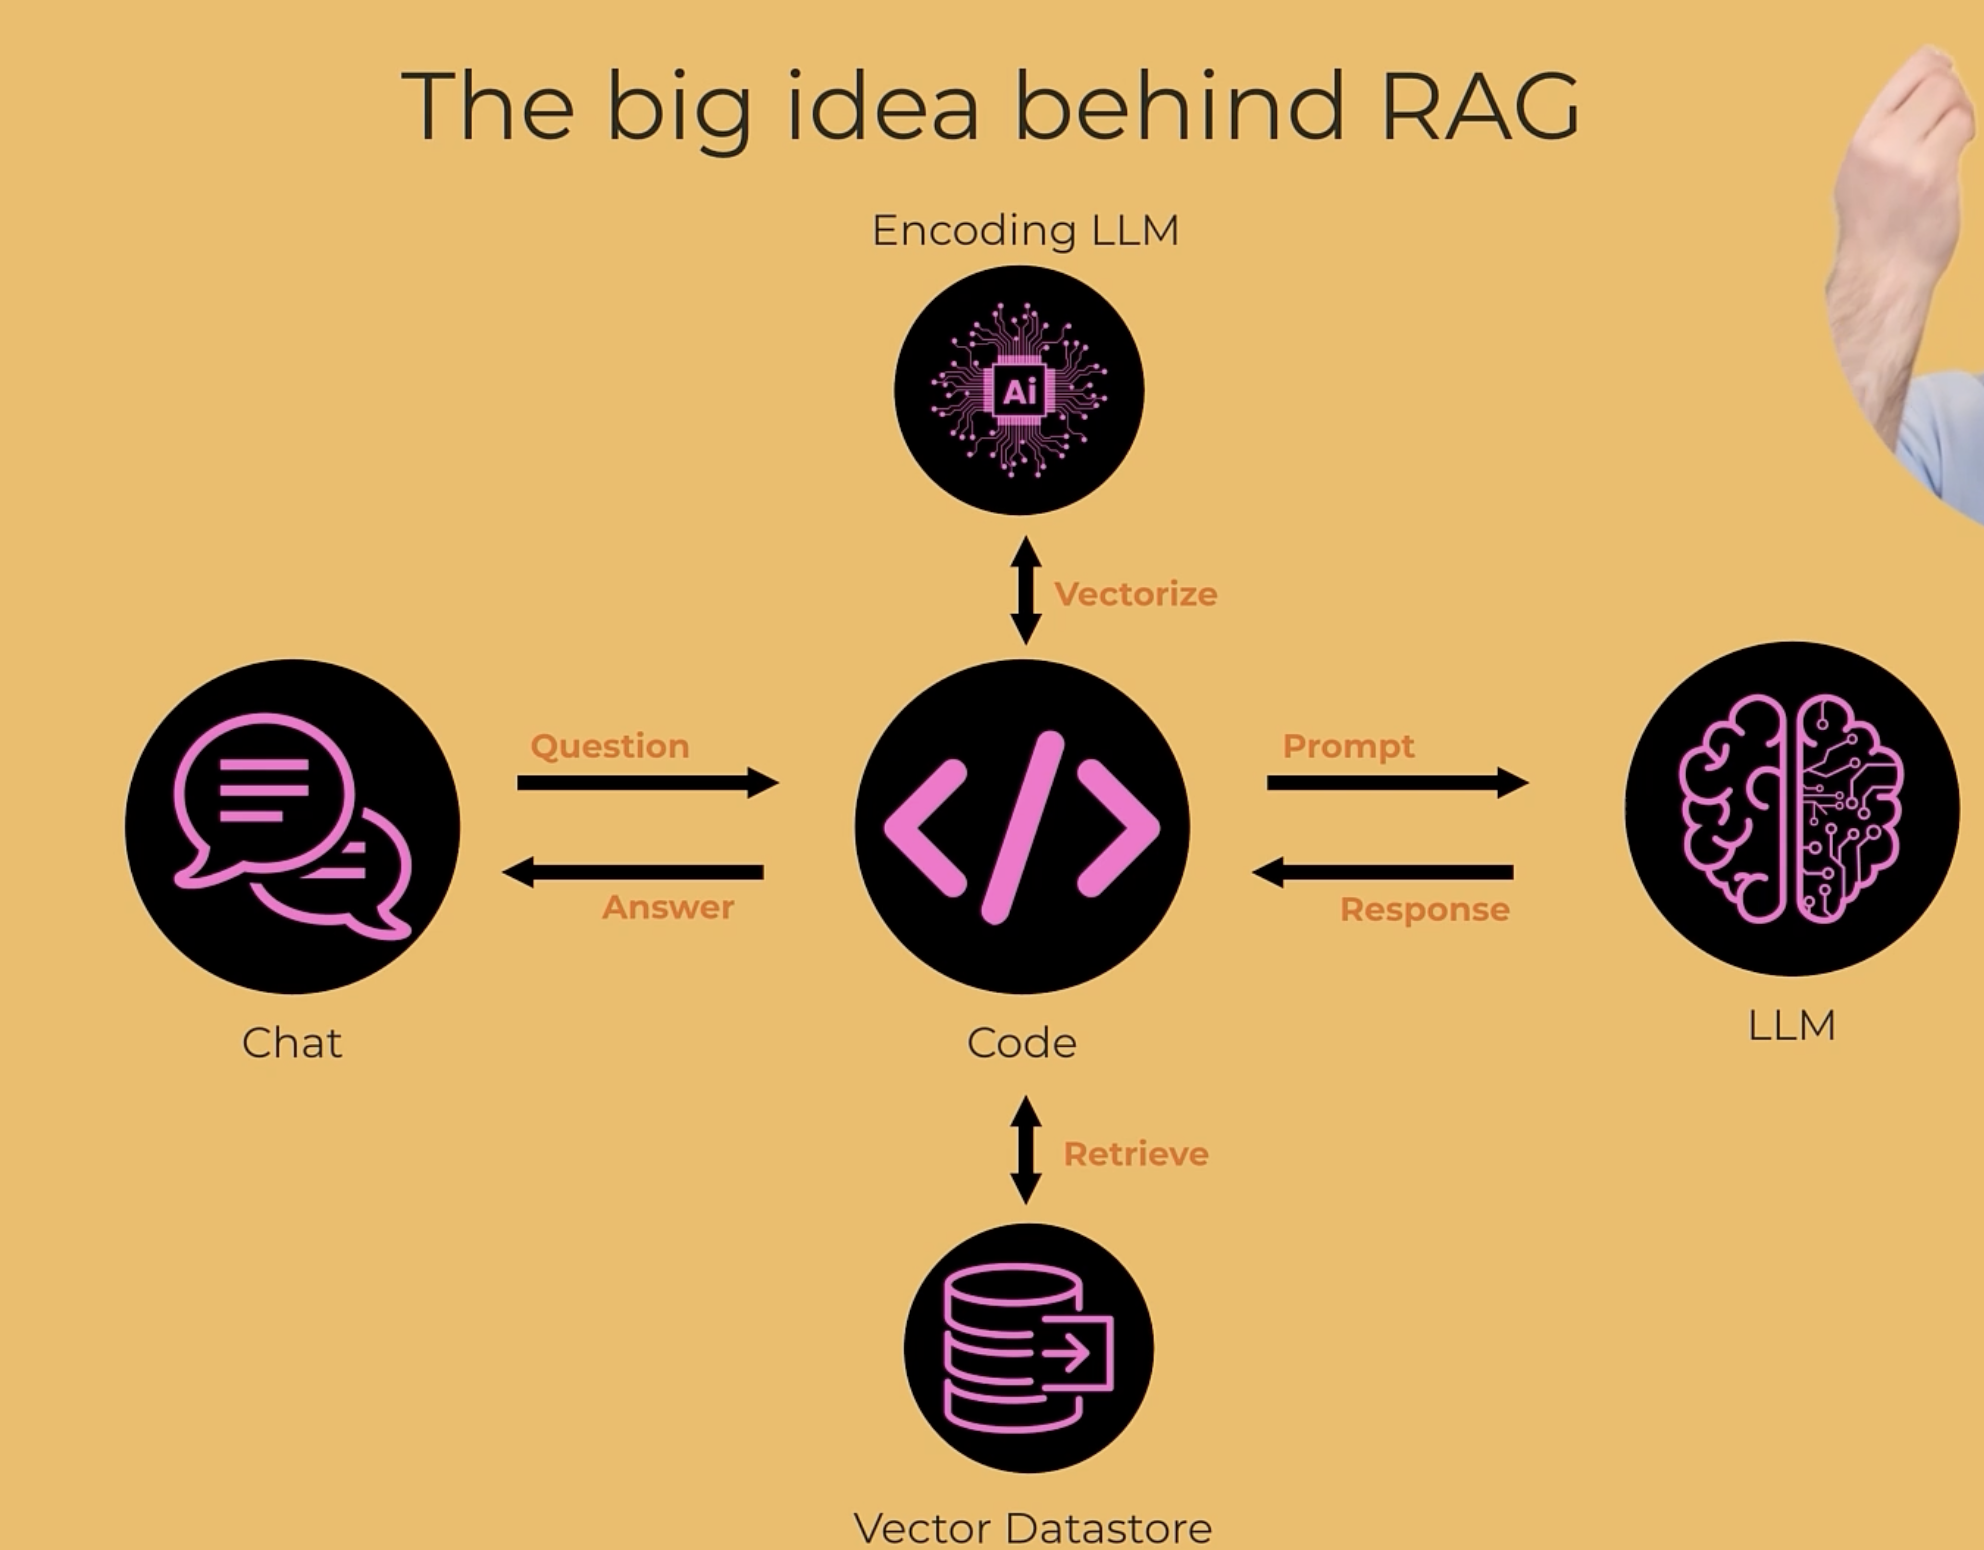


In [ ]:
- The Encoding LLM is independent of the LLM. The only purpose of the Encoding LLM is to find relevant information from the Vector Datastore. 
- Relevant Information means, have similar context or meaning, not the words search.

    

# 2. Vector DataStore

In [ ]:
# What is Vector DataStore
- A vector database is built to store and search semantic meaning, not raw text. 
- Key Points:
    • Vector DB stores embeddings of text chunks, not whole entities
    • Each chunk → one vector + metadata
    • User query is embedded using the same model
    • Similarity search retrieves top-K closest vectors
    • Cosine similarity is the most common metric
    • Retrieved chunks are used for search or RAG

# How does it store Information
- You typically split the information into chunks and store one vector per chunk.
- points in N-Dimension Vector
    •	Your question → one point
	•	Every stored chunk → one point
	•	Similar meaning → points lie closer together    

# How is a user question compared
- A question is converted into an embedding vector, which represents a single point in an N-dimensional vector space.
    1 question → 1 embedding → 1 point
    
- The same embedding model is used for both:
- Steps:
    User question
       ↓
    Embedding Model
       ↓
    Query Vector
       ↓
    Similarity Search in Vector DB (This query vector is compared with all stored vectors.)

    
# How does the comparison work?
- Similarity metrics
    1. Cosine Similarity   (most common)
        - Similarity = cos(angle between vectors)
        - Example
            1.0   → identical meaning
            0.8+  → very similar
            0.0   → unrelated
    2. Dot Product
    3. Euclidean Distance

- Example:
    - "Product A costs ₹999 per month" ↔ "monthly price of Product A"
    - Very small angle → High similarity

# What does the vector DB actually return?
- Top-K most similar chunks, not the answer itself.
    - Example (Top 3 results)
        1. Product A pricing         (score: 0.92)
        2. Product A discount policy (score: 0.81)
        3. Product A subscription    (score: 0.79)

- These chunks are then:
	- Returned directly (semantic search), OR
	- Passed to an LLM (RAG – Retrieval Augmented Generation)

# Why metadata matters
- Vector DBs always combine vector + metadata filtering.
- Example Query: Find info about Product A pricing
    WHERE company = 'ABC' AND product = 'Product A'''
- This meta data avoids:
    - Comparing against irrelevant companies
	- Scaling issues


# Issue 1
# What happens if you did store one vector per company?
    ❌ Pricing question mixes with history
    ❌ Legal info contaminates product meaning
    ❌ Poor retrieval accuracy
    ❌ No explainability

Q: A valid usecase to store multiple company in one vector
    - Company-level similarity
    - “Find companies similar to ABC”
    - Not question-answering    

# Why Vector Database
- Vector Database is very quick at quering about which piece of data is closest to the query vector.

In [ ]:
# Vector Database
1. Chroma
	•	Not an embedding model → it’s an open-source vector database.
	•	It stores embeddings and provides efficient similarity search (nearest-neighbor lookup).
	•	How it works with embeddings:
	•	You first generate embeddings (e.g., with OpenAI).
	•	Then you insert them into Chroma for fast retrieval.

Popular Vector Database:
    1. Open-Source: Chroma, Qdrant, FAISS (in-memory)
    2. Paid & scalable: Pinecone, Weaviate, ...
    3. Mainstream databases (Postgres, Mongo, Elastic,...)        

In [ ]:
# Storing data in Vector DataStore

1. Do not store unnecessary data
2. Insert only relevant information
3. Avoid unimportant or redundant data
4. Use Q&A and Markdown as the optimal format
    4.1 Question-answer pairs make searching easier
    4.2 Store directly retrievable, compact information
    4.3 Convert bad data (unreadable data in pdf) into Markdown
5. Extract essentail points (with LLAMA parsers or other parsers)
6. Use shorter chunks for higher hit rate
7. Use the right chunk size & overlap, and employ a text splitter
    7.1 Balance depth of detail with efficiency
    7.2 Too small chunks → missing context
    7.3 Too large chunks → poorer retrieval quality
    7.4 Use special chunking strategies like contextual retrieval
8. Use the appropriate RAG strategy
    8.1 Light RAG
    8.2 Graph RAG
    8.3 Standard RAG
9. Test the bot with queries
    9.1 Check whether it delivers the desired answers
    9.2 If necessary, adjust the chunking or overall structure
10. Data Preparation
    - For the LLM input, convert all kind of text CSV, pdf, text to Markdowns.
    - Remove the unnecessary data/ text/ images and clean the text. 
    - The final Markdown should have only important information.
    - Scraping Information from websites
        1. Use tool like firecrawler, to extract the information from html pages.
        2. Clean data, remove unnecessary information.
        3. Convert to Markdown.
    - Scraping Information from youtube videos
        1. Scrape the transcript from the video.
        2. Clean it and convert it to markdown.
    - For CSV
        1. Convert the product CSV to a markdown.

In [ ]:
# Chunking

Why chunking is important:
    - Embedding models have token limits
    - One giant vector loses fine-grained meaning
    - Retrieval quality becomes very poor
    - If we put a large document without chunking then the LLM will provide answer for the text written in document start and at end. LLM will not perform good with the text written in middle.

Rules of chunking:
 - Depending on the type of text:
     - Stories: 1,000-5,000 chunks (if the context window is large enough).
     - Shorter texts: 500-1,000
     - Items with lists and links: 100-500
 - Overlap = approx. 1-5%
    - E.g•, 1,000 = 10-50
 - Pricing
    - If we have a chunk size of 50K: then for each query, atleast a 50K tokens will be processed.
    - If we have a chunk size of 5K: than may 2 or 3 chunks, total of 5K * 3 = 15K will be processed.
 - Best, play a little bit, to find out the best chunk size.


# Chunking Data
Company ABC
├── About company            → vector_1
├── Product A overview       → vector_2
├── Product A pricing        → vector_3
├── Product A limitations    → vector_4
├── Product B overview       → vector_5
├── Compliance & legal       → vector_6

# Each Chunk Becomes
{
  id: "abc_productA_pricing",
  vector: [0.012, -0.44, ..., 0.98],
  metadata: {
    company: "ABC",
    product: "Product A",
    section: "pricing"
  }
}


- In Vector Database, Each ● is one chunk → one vector → one point.
           Dimension 3 (v3)
                ^
                |
                |        ●  Chunk C
                |
                |   ●  Chunk B
                |
                |______________________> Dimension 1 (v1)
               /
              /
             ●  Chunk A
           Dimension 2 (v2)    

# Performance
    - Chunking Strategy can have a significant impact on performance.
    - If we take very less size, then our question context might be in multiple chunks.

# 3. Encoder/ Embedding Models

In [ ]:
The Encoder Model turns text into a Vector Embedding. This is then stored in a Vector Database like Chroma.
Two Steps (Both are independent):
1. Encoder Model: Turning Text into vector that uses an Encoder Model.
2. Vector Database: Storing a vector into a vector database.

Encoder Models
1. word2vec (2013)
2. BERT (2018)
3. OpenAI
    - text-embedding-3-small
    - text-embedding-3-large
4. Google
    - gemini-embedding-001
5. Hugging Face Sentence Transformers
    - all-MiniLM-L6-v2

# 4. Evaluation

In [ ]:
# Evaluation
1. Curate a Test Set
    - Example questions set with the right context identified and reference answers provided. 
2. Measure Retrieval Metrics
    - How good our system is, in terms of retrieving the correct chunks.
    - Metrics
        1. MRR (Mean Reciprocal Rank)
            - 1 means, the first chunk has the correct answer.
            - Formula: Average inverse rank of first hit.
                - If 1st chunk has correct answer then 1, if 2nd chunk has correct answer then (1/2), and so on (1/3)
        2. nDCG (Normalized Discounted Cumulative Gain
            - Did relevant chunks get ranked higher up
        3. Recall@K
            - Recall@K: Proportion of tests where relevant context was in the top K chunks.
            - If Recall@3 has value 0.5, it means the 50% of the times, the relevant answer was in the top 3 chunks.
        4. Precision@K = Proportion of the top K chunks that are relevant
            - How much % of top K chunks are relevant.
        5. Keyword Coverage metric
 
3. Measure Answers
    - LLM as a judge: score provided answers against criteria like accuracy, completeness and relevance
4. Gather end user feedback on how a good answer is.


In [ ]:
# RAG Advance Techniques
1. Chunking R&D: experiment with chunking strategy (changing chunk size, fetch top N results)
2. Encder R&D: Select the best Encoder Model based on test set.
3.Improve Prompts: general content, the current date, relevant context and history
4. Document pre-processing: use an LLM to make the chunks and/or text for encoding
    - Ask ChatGPT to turn a document into a chunks, so it is best suitable for vector DB.
5. Query rewriting: use an LLM to convert the users question to a RAG query, and then perform the RAG query.
    - Sometime it performs very badly, as the LLM might remove some important keyword from the user query.
6. Query expansion: use an LLM to turn the question into multiple RAG queries
7. Re-ranking: b  use an LLM to re-order the chunks and remove irrelevant chunks.
8. Hierarchical: use an LLM to summarize at multiple levels
    - Lets say the query is "How many employees have salary less than K"
        - LLM wont be able to answer it. So better way would be, create a chunk/ multiple chunks that summaries all the employees information. like a table with name of all employees, salary, and other basic details.
9. Graph RAG: retrieve content closely related to similar documents            
    - Graph RAG DB are usually required, when there is a lot of relationship b/w the data/ chunks.
10. Agentic RAG: use Agents for retrieval, combining with Memory and Tools such as SQL
    - This is the best way of all, giving LLM all the tools to query on SQL, vector database. In that case, LLM will write the query and execute it. It will perform the re-ranking and everything by itself.

# 6. Steps for RAG

In [ ]:
1. Read in the documents in all folders
2. Divide into chunks
3. Vectorize and store


Pros of RAG:
    - Rapid time to market
    - Give an LLM vast expertise
    - Save on context length
    - Avoid distracting with irrelevant context

Cons of RAG:
    - It's a hack, very much trial and error approach.
    - Unexpected "I don't Know" response from LLM.
    - Great idea can have poor results.

    